In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split
import torch.nn as nn
import torch.nn.init as init
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

total_train_size = len(full_train_dataset)
train_size = int(0.8 * total_train_size)
val_size = int(0.2 * total_train_size)


train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 197kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.65MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.0MB/s]


In [3]:
# Optional: Create DataLoaders for each set
batch_size = 64

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


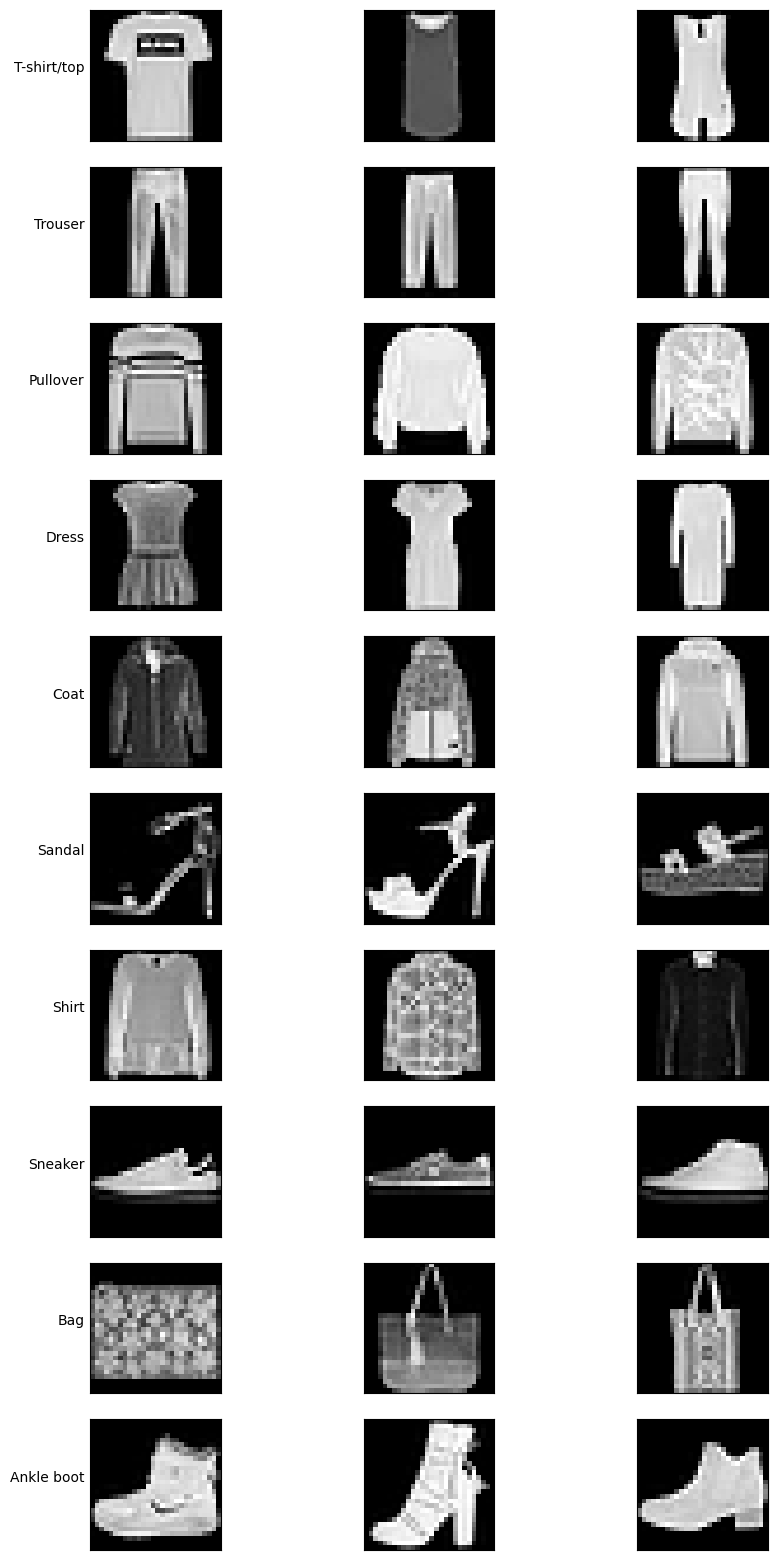

In [4]:
fashion_mnist_classes = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

sampled_images_per_class = {class_id: [] for class_id in fashion_mnist_classes.keys()}
samples_count = {class_id: 0 for class_id in fashion_mnist_classes.keys()}

for img, label in full_train_dataset:
    label_id = label.item() if isinstance(label, torch.Tensor) else label
    if samples_count[label_id] < 3:
        sampled_images_per_class[label_id].append(img.squeeze().numpy())
        samples_count[label_id] += 1

    if all(count == 3 for count in samples_count.values()):
        break

fig, axes = plt.subplots(len(fashion_mnist_classes), 3, figsize=(10, 20))

for i, (class_id, class_name) in enumerate(fashion_mnist_classes.items()):
    for j in range(3):
        ax = axes[i, j]
        if j < len(sampled_images_per_class[class_id]):
            ax.imshow(sampled_images_per_class[class_id][j], cmap='gray')
            ax.set_xticks([])
            ax.set_yticks([])
            if j == 0:
                ax.set_ylabel(class_name, rotation=0, ha='right', fontsize=10)
        else:
            ax.axis('off')
plt.show()

(Q) What varies through the images?
The main thing that varies through the images are the shape and size. tshirts and shirts occupy a broader space while sandals occupy smaller, most bags are rectangular, etc.

(Q) What information is essential for classification?
Factors like orientation, outline of the item, distinct features like handles in bag, collars in shirts,heels in sandals is essential for classification.

(Q) What information is irrelevant? Pixel intensity is irrelevant, color pallette is also not required since all images are grayscaled

## Building Model

In [5]:
class Autoencoder(nn.Module):
  def __init__(self,input_dim,latent_dim):
    super(Autoencoder,self).__init__()
    self.encoder = nn.Sequential(
      nn.Linear(input_dim,256),
      nn.ReLU(),

      nn.Linear(256,128),
      nn.ReLU(),

      nn.Linear(128,latent_dim)
    )
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim,128),
        nn.ReLU(),

        nn.Linear(128,256),
        nn.ReLU(),

        nn.Linear(256,input_dim)
    )
    self.init_weights()

  def init_weights(self):
    for m in self.modules():
      if isinstance(m,nn.Linear):
        init.kaiming_normal_(m.weight,nonlinearity='relu')
        if m.bias is not None:
          init.constant_(m.bias,0)

  def forward(self,x):
    return self.decoder(self.encoder(x))

In [6]:
model = Autoencoder(input_dim=784,latent_dim=8)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
import copy
def train_autoencoder(latent_dim,input_dim,train_loader,val_loader,device,epochs = 30,patience = 5):

    model = Autoencoder(input_dim=input_dim, latent_dim=latent_dim)
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    counter = 0
    best_model_wts = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, _ in train_loader:
            optimizer.zero_grad()
            batch_x_flat = batch_x.view(-1, input_dim).to(device)

            outputs = model(batch_x_flat)
            loss = criterion(outputs, batch_x_flat)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x_val, _ in val_loader:
                batch_x_val_flat = batch_x_val.view(-1, input_dim).to(device)
                v_out = model(batch_x_val_flat)
                val_loss += criterion(v_out, batch_x_val_flat).item()
        val_loss /= len(val_loader)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss:{train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= patience:
                if best_model_wts is not None:
                    model.load_state_dict(best_model_wts)
                break

    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)

    return model


In [9]:
def calculate_test_loss(model, test_loader, input_dim, device):
    model.eval()
    criterion = nn.MSELoss()
    test_loss = 0
    with torch.no_grad():
        test_batch_x_sample, _ = next(iter(test_loader))
        test_batch_x_flat = test_batch_x_sample.view(-1, input_dim).to(device)

        test_outputs = model(test_batch_x_flat)
        test_loss = criterion(test_outputs, test_batch_x_flat).item()

    return test_loss, test_batch_x_sample

In [10]:
import matplotlib.pyplot as plt

def display_reconstructions(model, test_batch_x_sample, input_dim, device, latent_dim):
    model.eval()
    with torch.no_grad():
        plt.figure(figsize=(20, 4))
        test_batch_x_flat = test_batch_x_sample.view(-1, input_dim).to(device)
        for i in range(10):
            original_image_flat = test_batch_x_flat[i:i+1, :].cpu()
            original_image_tensor = test_batch_x_sample[i:i+1, :, :, :].cpu()

            latent_representation = model.encoder(original_image_flat.to(device))
            reconstructed_image_flat = model.decoder(latent_representation).cpu()

            original_image_display = original_image_tensor.squeeze().numpy()
            reconstructed_image_display = reconstructed_image_flat.view(28, 28).numpy()

            plt.subplot(2, 10, i + 1)
            plt.title(f"Original {i+1}")
            plt.imshow(original_image_display, cmap='gray')
            plt.axis('off')

            plt.subplot(2, 10, i + 11)
            plt.title(f"Recon {i+1}")
            plt.imshow(reconstructed_image_display, cmap='gray')
            plt.axis('off')

        plt.tight_layout()
        plt.show()

## Training Models

Epoch 1/30 | Train Loss:0.0571 | Val Loss: 0.0364
Epoch 2/30 | Train Loss:0.0351 | Val Loss: 0.0337
Epoch 3/30 | Train Loss:0.0334 | Val Loss: 0.0327
Epoch 4/30 | Train Loss:0.0321 | Val Loss: 0.0316
Epoch 5/30 | Train Loss:0.0312 | Val Loss: 0.0306
Epoch 6/30 | Train Loss:0.0304 | Val Loss: 0.0298
Epoch 7/30 | Train Loss:0.0298 | Val Loss: 0.0292
Epoch 8/30 | Train Loss:0.0306 | Val Loss: 0.0306
Epoch 9/30 | Train Loss:0.0304 | Val Loss: 0.0307
Epoch 10/30 | Train Loss:0.0296 | Val Loss: 0.0290
Epoch 11/30 | Train Loss:0.0292 | Val Loss: 0.0287
Epoch 12/30 | Train Loss:0.0286 | Val Loss: 0.0281
Epoch 13/30 | Train Loss:0.0281 | Val Loss: 0.0278
Epoch 14/30 | Train Loss:0.0276 | Val Loss: 0.0276
Epoch 15/30 | Train Loss:0.0273 | Val Loss: 0.0273
Epoch 16/30 | Train Loss:0.0271 | Val Loss: 0.0272
Epoch 17/30 | Train Loss:0.0271 | Val Loss: 0.0273
Epoch 18/30 | Train Loss:0.0269 | Val Loss: 0.0271
Epoch 19/30 | Train Loss:0.0267 | Val Loss: 0.0265
Epoch 20/30 | Train Loss:0.0265 | Val Lo

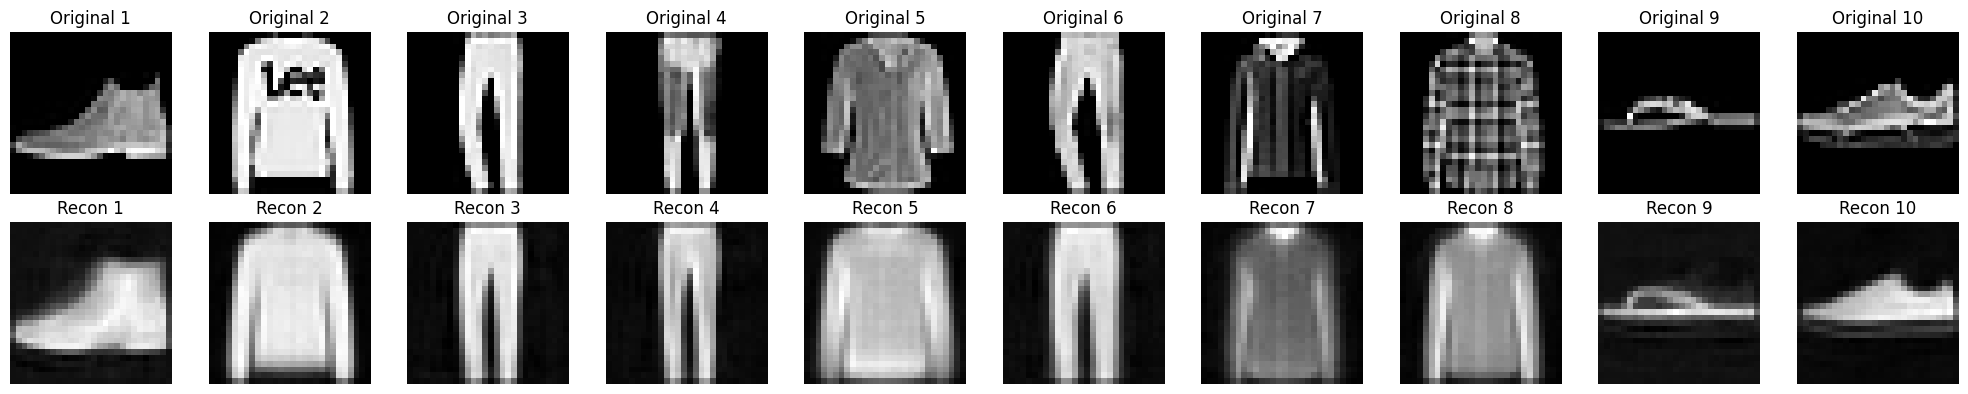

In [11]:
model_2 = train_autoencoder(
    latent_dim=2,
    input_dim=784,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)
test_loss_2, test_batch_x_sample_2 = calculate_test_loss(model_2, test_loader, 784, device)
display_reconstructions(model_2, test_batch_x_sample_2, 784, device, 2)

Epoch 1/30 | Train Loss:0.0380 | Val Loss: 0.0229
Epoch 2/30 | Train Loss:0.0206 | Val Loss: 0.0190
Epoch 3/30 | Train Loss:0.0180 | Val Loss: 0.0172
Epoch 4/30 | Train Loss:0.0166 | Val Loss: 0.0160
Epoch 5/30 | Train Loss:0.0156 | Val Loss: 0.0152
Epoch 6/30 | Train Loss:0.0148 | Val Loss: 0.0145
Epoch 7/30 | Train Loss:0.0142 | Val Loss: 0.0140
Epoch 8/30 | Train Loss:0.0138 | Val Loss: 0.0138
Epoch 9/30 | Train Loss:0.0135 | Val Loss: 0.0134
Epoch 10/30 | Train Loss:0.0132 | Val Loss: 0.0132
Epoch 11/30 | Train Loss:0.0129 | Val Loss: 0.0130
Epoch 12/30 | Train Loss:0.0128 | Val Loss: 0.0128
Epoch 13/30 | Train Loss:0.0126 | Val Loss: 0.0126
Epoch 14/30 | Train Loss:0.0124 | Val Loss: 0.0126
Epoch 15/30 | Train Loss:0.0123 | Val Loss: 0.0124
Epoch 16/30 | Train Loss:0.0122 | Val Loss: 0.0122
Epoch 17/30 | Train Loss:0.0121 | Val Loss: 0.0122
Epoch 18/30 | Train Loss:0.0120 | Val Loss: 0.0123
Epoch 19/30 | Train Loss:0.0119 | Val Loss: 0.0120
Epoch 20/30 | Train Loss:0.0118 | Val Lo

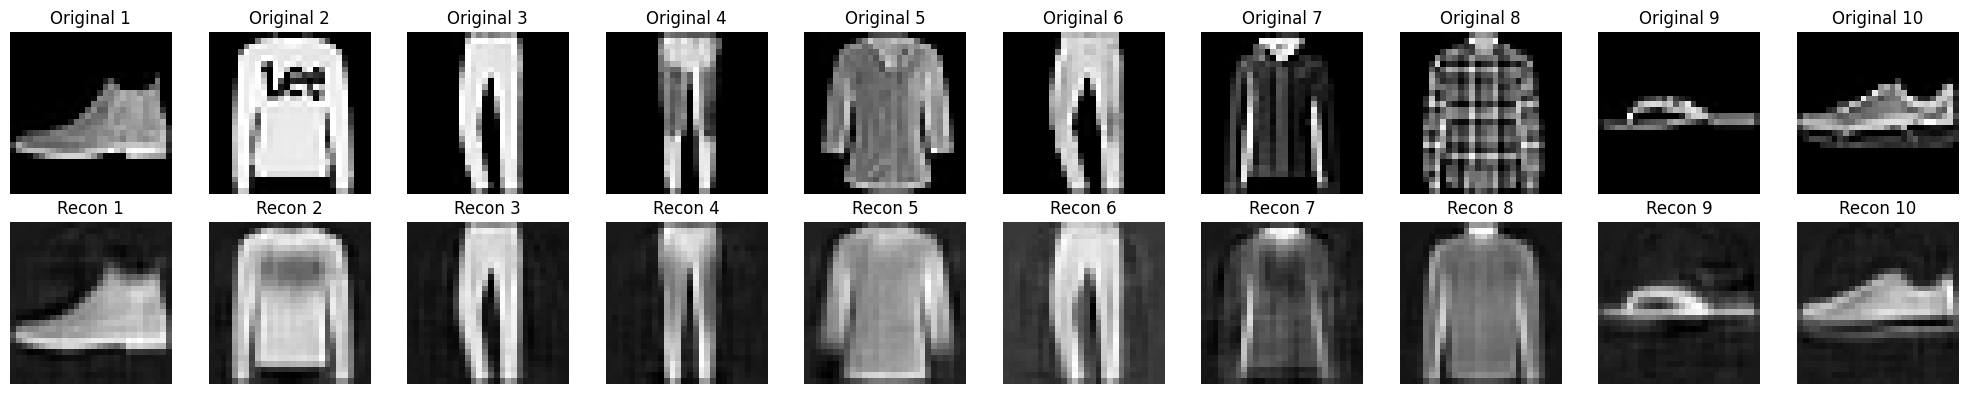

In [12]:
model_32 = train_autoencoder(
    latent_dim=32,
    input_dim=784,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)
test_loss_32, test_batch_x_sample_32 = calculate_test_loss(model_32, test_loader, 784, device)
display_reconstructions(model_32, test_batch_x_sample_32, 784, device, 32)


Epoch 1/30 | Train Loss:0.0390 | Val Loss: 0.0231
Epoch 2/30 | Train Loss:0.0209 | Val Loss: 0.0193
Epoch 3/30 | Train Loss:0.0182 | Val Loss: 0.0173
Epoch 4/30 | Train Loss:0.0167 | Val Loss: 0.0163
Epoch 5/30 | Train Loss:0.0158 | Val Loss: 0.0156
Epoch 6/30 | Train Loss:0.0152 | Val Loss: 0.0149
Epoch 7/30 | Train Loss:0.0147 | Val Loss: 0.0145
Epoch 8/30 | Train Loss:0.0143 | Val Loss: 0.0142
Epoch 9/30 | Train Loss:0.0140 | Val Loss: 0.0140
Epoch 10/30 | Train Loss:0.0137 | Val Loss: 0.0136
Epoch 11/30 | Train Loss:0.0134 | Val Loss: 0.0135
Epoch 12/30 | Train Loss:0.0132 | Val Loss: 0.0132
Epoch 13/30 | Train Loss:0.0130 | Val Loss: 0.0130
Epoch 14/30 | Train Loss:0.0129 | Val Loss: 0.0129
Epoch 15/30 | Train Loss:0.0127 | Val Loss: 0.0129
Epoch 16/30 | Train Loss:0.0126 | Val Loss: 0.0127
Epoch 17/30 | Train Loss:0.0125 | Val Loss: 0.0126
Epoch 18/30 | Train Loss:0.0124 | Val Loss: 0.0125
Epoch 19/30 | Train Loss:0.0123 | Val Loss: 0.0124
Epoch 20/30 | Train Loss:0.0122 | Val Lo

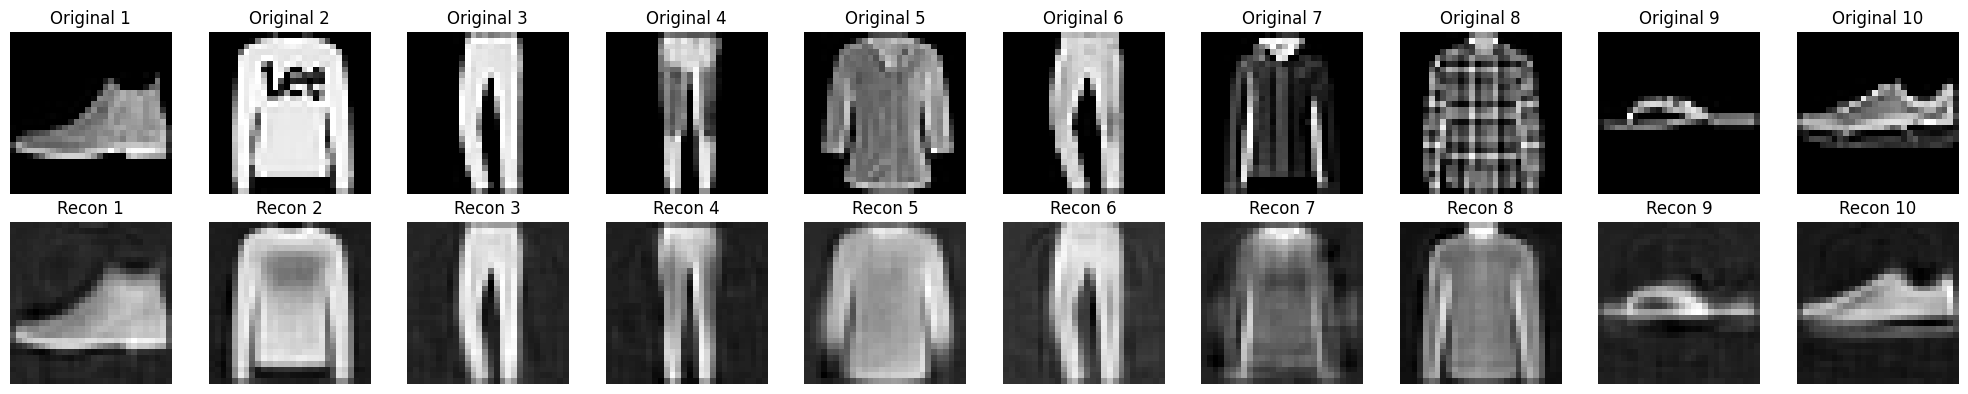

In [14]:
model_64 = train_autoencoder(
    latent_dim=64,
    input_dim=784,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)
test_loss_64, test_batch_x_sample_64 = calculate_test_loss(model_64, test_loader, 784, device)
display_reconstructions(model_64, test_batch_x_sample_64, 784, device, 64)


(Q) What details are lost in small latent spaces? Details like pattern on the tshirts and shirts, sleeves in the tshirts, etc are almost lost.

(Q) What does large model preserve that may not matter? It preserves subtle background variations that may not be needed during classification. It may even preserve the noise from original images.

(Q) When does reconstruction look good but feels wrong? The reconstructed image may look good if the autoencoder just copy the inout to output. What matters is whether it understands the image or not. It may perform well on reconstruction but if the latent space is not useful and does not represent the classes well then the purpose of AE has not been achieved.

###Visualization

In [15]:
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_latent_representations(model, data_loader, input_dim, device):
    latent_representations = []
    labels = []
    model.eval()
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x_flat = batch_x.view(-1, input_dim).to(device)
            latent = model.encoder(batch_x_flat).cpu().numpy()
            latent_representations.append(latent)
            labels.append(batch_y.numpy())
    return np.concatenate(latent_representations), np.concatenate(labels)

fashion_mnist_classes = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

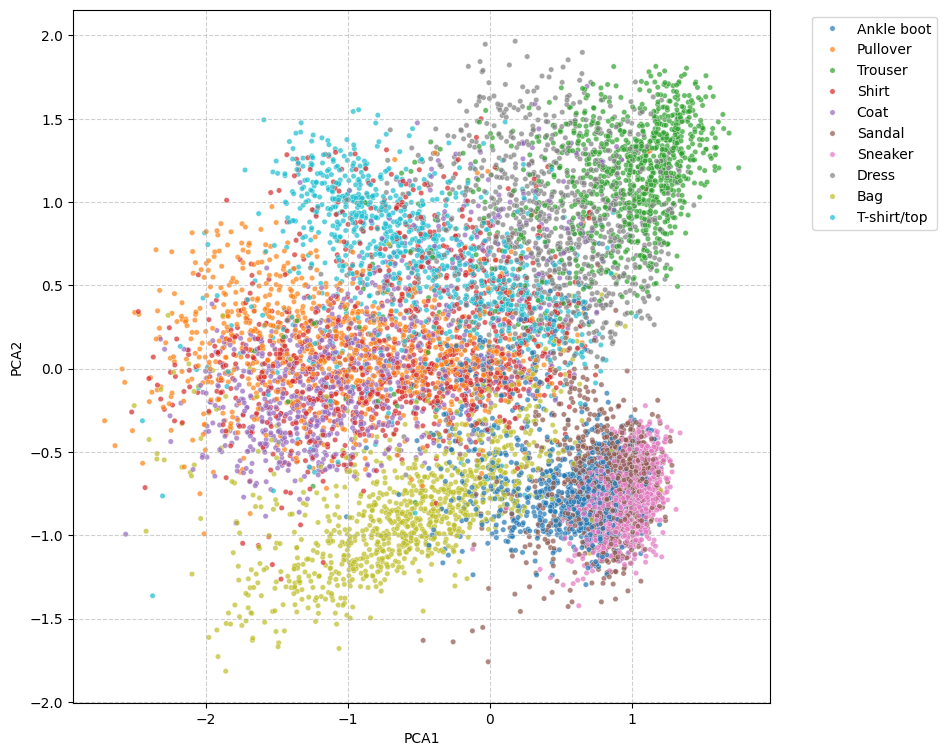

In [16]:
latent_reps_32, labels_32 = extract_latent_representations(model_32, test_loader, 784, device)
pca_32 = PCA(n_components=2)
latent_reps_2d_32 = pca_32.fit_transform(latent_reps_32)

df_latent_32 = pd.DataFrame({
    'PCA1': latent_reps_2d_32[:, 0],
    'PCA2': latent_reps_2d_32[:, 1],
    'label': labels_32
})

df_latent_32['class_name'] = df_latent_32['label'].map(fashion_mnist_classes)

plt.figure(figsize=(9, 9))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='class_name', data=df_latent_32,
    palette=sns.color_palette('tab10', n_colors=10),
    legend='full', alpha=0.7, s=15
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

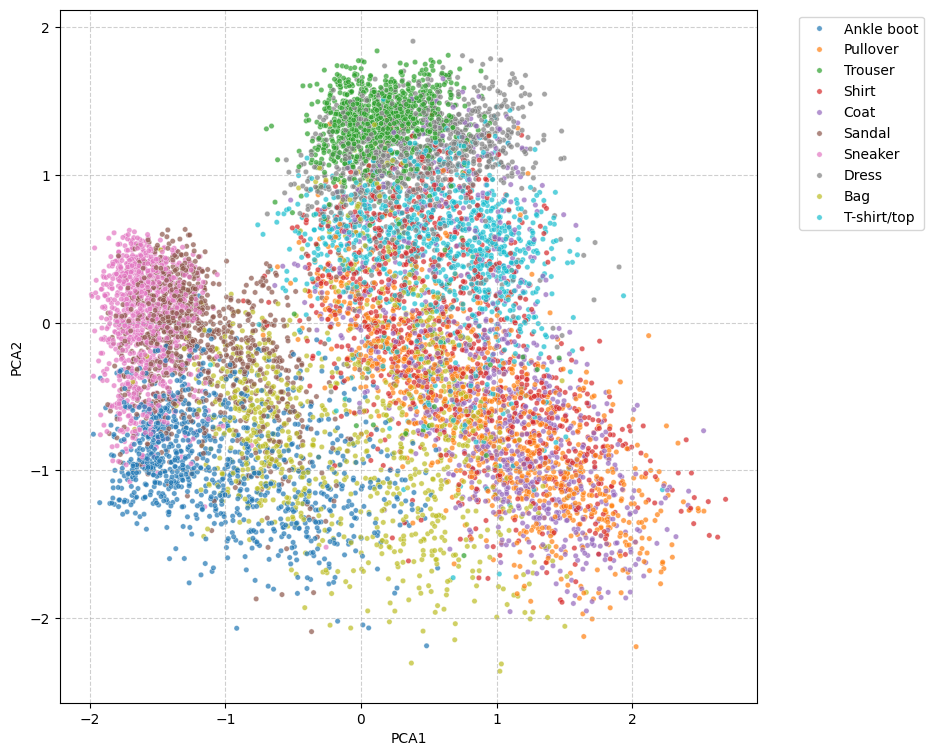

In [17]:
latent_reps_64, labels_64 = extract_latent_representations(model_64, test_loader, 784, device)

pca_64 = PCA(n_components=2)
latent_reps_2d_64 = pca_64.fit_transform(latent_reps_64)

df_latent_64 = pd.DataFrame({
    'PCA1': latent_reps_2d_64[:, 0],
    'PCA2': latent_reps_2d_64[:, 1],
    'label': labels_64
})

df_latent_64['class_name'] = df_latent_64['label'].map(fashion_mnist_classes)

plt.figure(figsize=(9, 9))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='class_name', data=df_latent_64,
    palette=sns.color_palette('tab10', n_colors=10),
    legend='full', alpha=0.7, s=15
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

(Q) Are similar classes grouped together? Yes similar classes are grouped together such as tshirt and shirt, sneakers and ankle boots. But some are not together such as trouser and pullover.

(Q) Are classes seperable? Yes most classes are seperable but some are all over the place like pullover, coat, and shirt are overlapping eachother.

(Q) Yes latent space does represent latent meaning. It understood the broader aspects of data but still has scope for improvement. It should perform better if i increase the latent dim further and increase the number of hidden layers in the MLP

## Interpolation

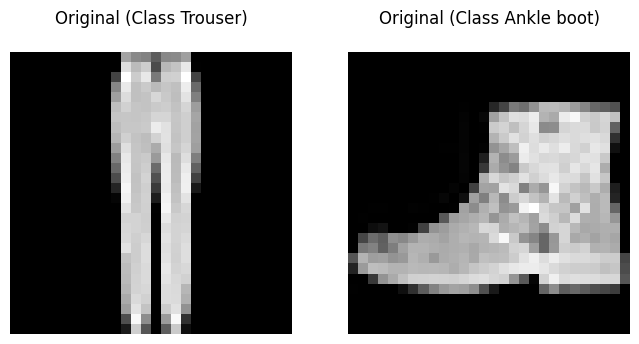

In [18]:
class_id_1 = 1
class_id_2 = 9

image1_tensor = None
image2_tensor = None

for img, label in test_dataset:
    label_item = label.item() if isinstance(label, torch.Tensor) else label

    if label_item == class_id_1:
        image1_tensor = img
        label1 = label_item
    elif label_item == class_id_2:
        image2_tensor = img
        label2 = label_item

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image1_tensor.squeeze().numpy(), cmap='gray')
plt.title(f"Original (Class {fashion_mnist_classes[label1]})\n")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image2_tensor.squeeze().numpy(), cmap='gray')
plt.title(f"Original (Class {fashion_mnist_classes[label2]})\n")
plt.axis('off')
plt.show()

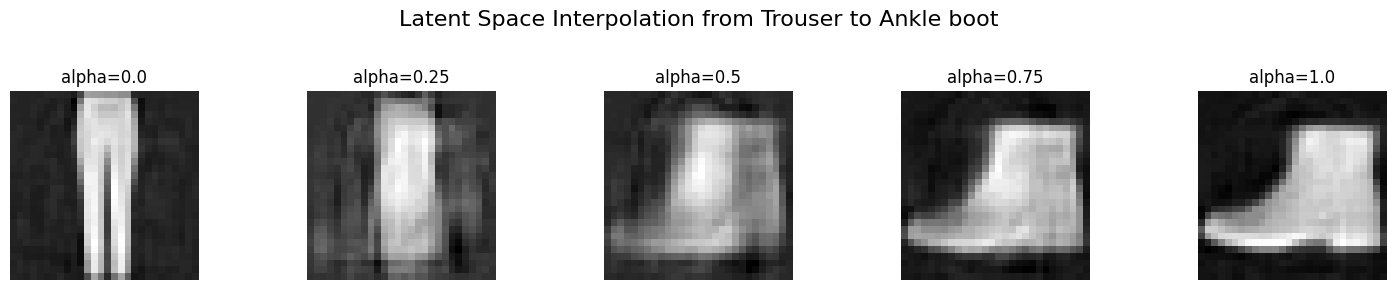

In [19]:
model_to_use = model_64
input_dim = 784
latent_dim = 64

model_to_use.eval()

image1_flat = image1_tensor.view(1, -1).to(device)
image2_flat = image2_tensor.view(1, -1).to(device)

with torch.no_grad():
    z1 = model_to_use.encoder(image1_flat)
    z2 = model_to_use.encoder(image2_flat)

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

interpolated_images = []

with torch.no_grad():
    for alpha in alphas:
        z_alpha = (1 - alpha) * z1 + alpha * z2
        decoded_image_flat = model_to_use.decoder(z_alpha)
        interpolated_images.append(decoded_image_flat.cpu().view(28, 28).numpy())

plt.figure(figsize=(15, 3))
plt.suptitle(f"Latent Space Interpolation from {fashion_mnist_classes[label1]} to {fashion_mnist_classes[label2]}", fontsize=16)
for i, img in enumerate(interpolated_images):
    plt.subplot(1, len(alphas), i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"alpha={alphas[i]}")
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()


## Interpolation for Bag and Trouser

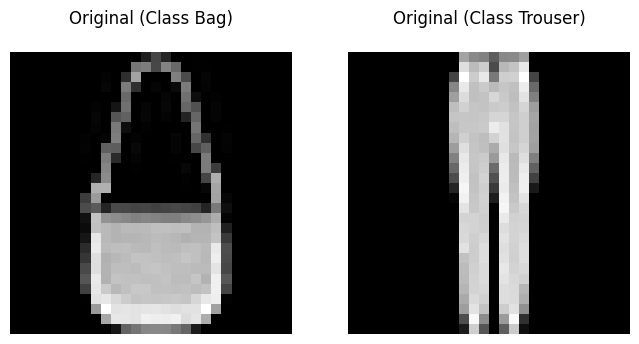

In [20]:
class_id_1_new = 8 # Bag
class_id_2_new = 1 # Trouser

image1_tensor_new = None
image2_tensor_new = None

for img, label in test_dataset:
    label_item = label.item() if isinstance(label, torch.Tensor) else label

    if label_item == class_id_1_new:
        image1_tensor_new = img
        label1_new = label_item
    elif label_item == class_id_2_new:
        image2_tensor_new = img
        label2_new = label_item

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image1_tensor_new.squeeze().numpy(), cmap='gray')
plt.title(f"Original (Class {fashion_mnist_classes[label1_new]})\n")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image2_tensor_new.squeeze().numpy(), cmap='gray')
plt.title(f"Original (Class {fashion_mnist_classes[label2_new]})\n")
plt.axis('off')
plt.show()

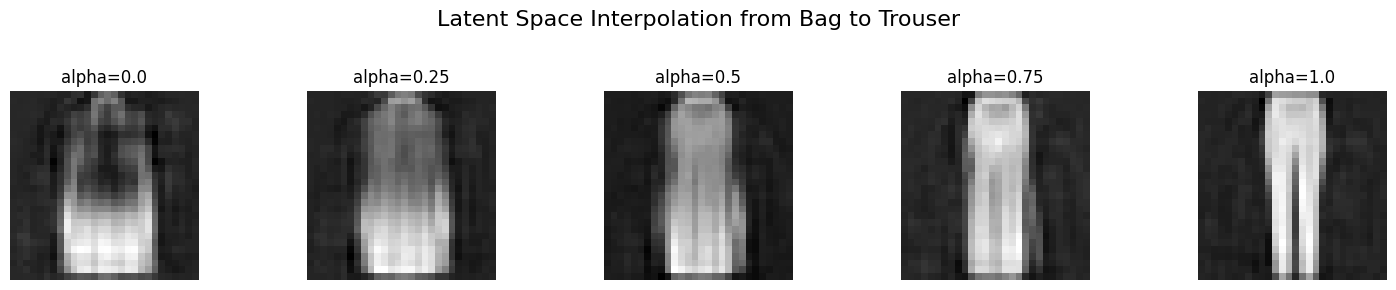

In [21]:
model_to_use = model_64
input_dim = 784
latent_dim = 64

model_to_use.eval()

image1_flat_new = image1_tensor_new.view(1, -1).to(device)
image2_flat_new = image2_tensor_new.view(1, -1).to(device)

with torch.no_grad():
    z1_new = model_to_use.encoder(image1_flat_new)
    z2_new = model_to_use.encoder(image2_flat_new)

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

interpolated_images_new = []

with torch.no_grad():
    for alpha in alphas:
        z_alpha_new = (1 - alpha) * z1_new + alpha * z2_new
        decoded_image_flat_new = model_to_use.decoder(z_alpha_new)
        interpolated_images_new.append(decoded_image_flat_new.cpu().view(28, 28).numpy())

plt.figure(figsize=(15, 3))
plt.suptitle(f"Latent Space Interpolation from {fashion_mnist_classes[label1_new]} to {fashion_mnist_classes[label2_new]}", fontsize=16)
for i, img in enumerate(interpolated_images_new):
    plt.subplot(1, len(alphas), i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"alpha={alphas[i]}")
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

## Interpolation for T-shirt/top and Pullover

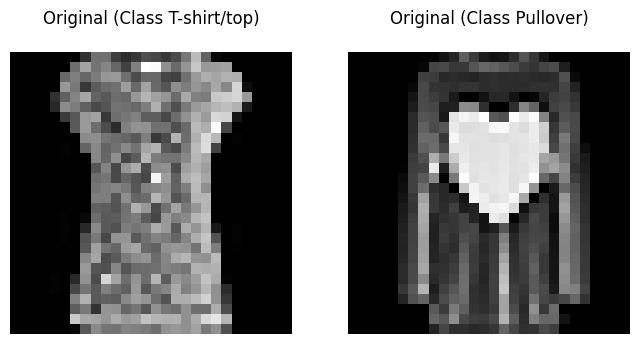

In [22]:
class_id_1_new_2 = 0 # T-shirt/top
class_id_2_new_2 = 2 # Pullover

image1_tensor_new_2 = None
image2_tensor_new_2 = None

for img, label in test_dataset:
    label_item = label.item() if isinstance(label, torch.Tensor) else label

    if label_item == class_id_1_new_2:
        image1_tensor_new_2 = img
        label1_new_2 = label_item
    elif label_item == class_id_2_new_2:
        image2_tensor_new_2 = img
        label2_new_2 = label_item

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image1_tensor_new_2.squeeze().numpy(), cmap='gray')
plt.title(f"Original (Class {fashion_mnist_classes[label1_new_2]})\n")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image2_tensor_new_2.squeeze().numpy(), cmap='gray')
plt.title(f"Original (Class {fashion_mnist_classes[label2_new_2]})\n")
plt.axis('off')
plt.show()

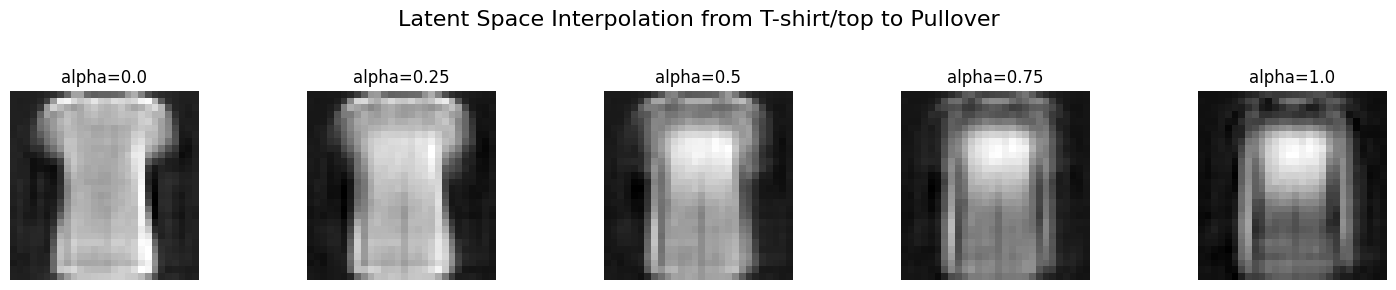

In [23]:
model_to_use = model_64
input_dim = 784
latent_dim = 64

model_to_use.eval()

image1_flat_new_2 = image1_tensor_new_2.view(1, -1).to(device)
image2_flat_new_2 = image2_tensor_new_2.view(1, -1).to(device)

with torch.no_grad():
    z1_new_2 = model_to_use.encoder(image1_flat_new_2)
    z2_new_2 = model_to_use.encoder(image2_flat_new_2)

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

interpolated_images_new_2 = []

with torch.no_grad():
    for alpha in alphas:
        z_alpha_new_2 = (1 - alpha) * z1_new_2 + alpha * z2_new_2
        decoded_image_flat_new_2 = model_to_use.decoder(z_alpha_new_2)
        interpolated_images_new_2.append(decoded_image_flat_new_2.cpu().view(28, 28).numpy())

plt.figure(figsize=(15, 3))
plt.suptitle(f"Latent Space Interpolation from {fashion_mnist_classes[label1_new_2]} to {fashion_mnist_classes[label2_new_2]}", fontsize=16)
for i, img in enumerate(interpolated_images_new_2):
    plt.subplot(1, len(alphas), i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"alpha={alphas[i]}")
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()